<a href="https://colab.research.google.com/github/manasamorthad/DeepLearning/blob/main/week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Number of classes: 24
Epoch 1/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.6334 - loss: 1.2735 - val_accuracy: 0.9120 - val_loss: 0.3205
Epoch 2/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9650 - loss: 0.1525 - val_accuracy: 0.9942 - val_loss: 0.0500
Epoch 3/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9957 - loss: 0.0320 - val_accuracy: 0.9996 - val_loss: 0.0149
Epoch 4/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9999 - loss: 0.0089 - val_accuracy: 0.9996 - val_loss: 0.0061
Epoch 5/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9996 - val_loss: 0.0037
Test Accuracy: 0.906302273273468


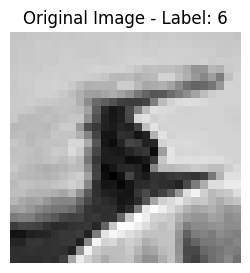

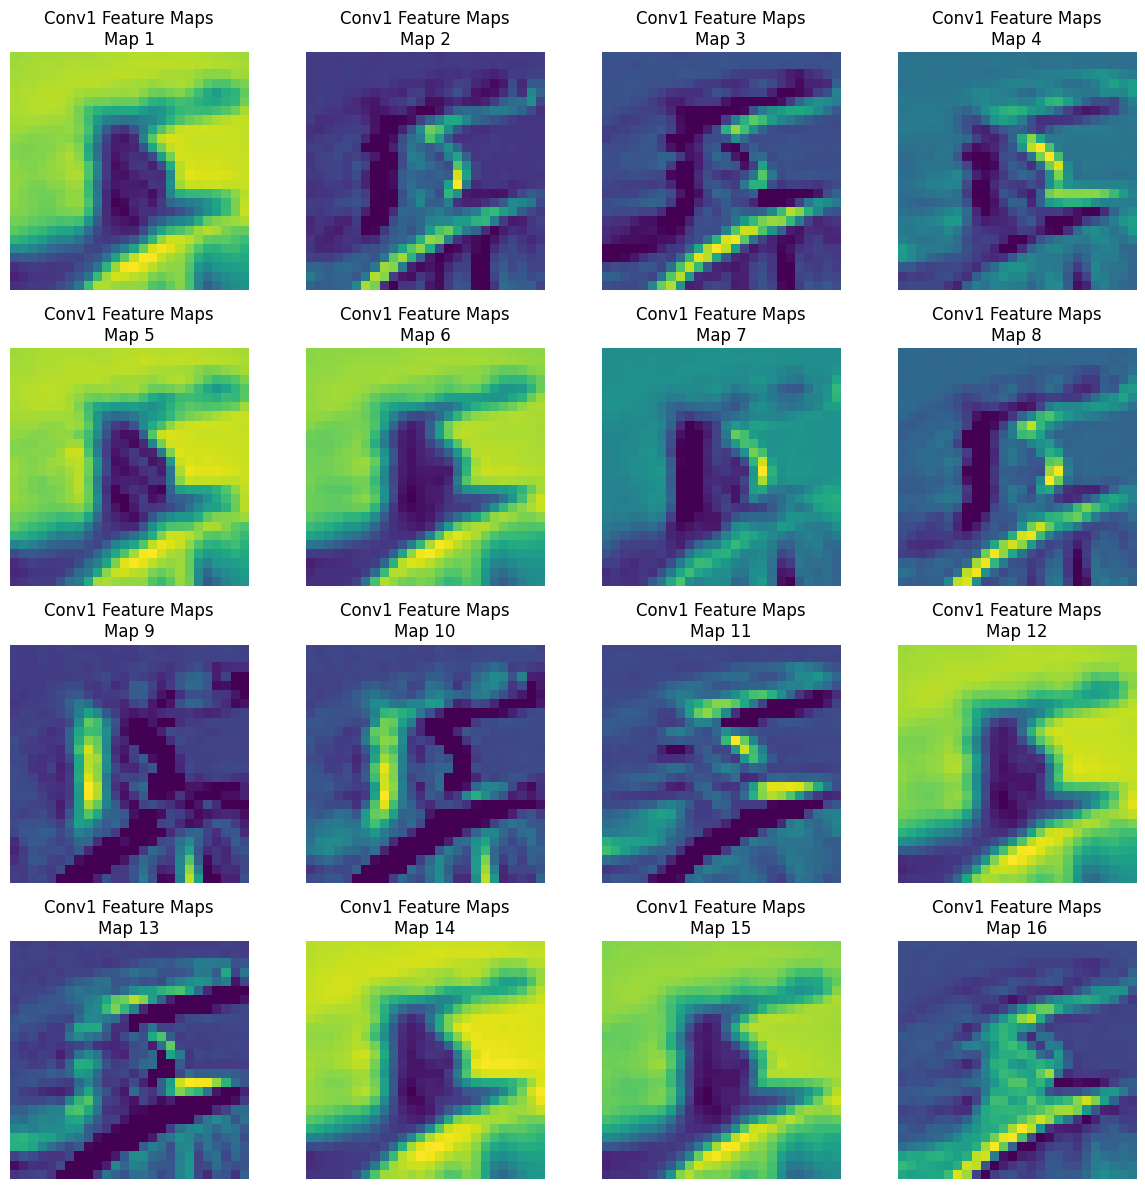

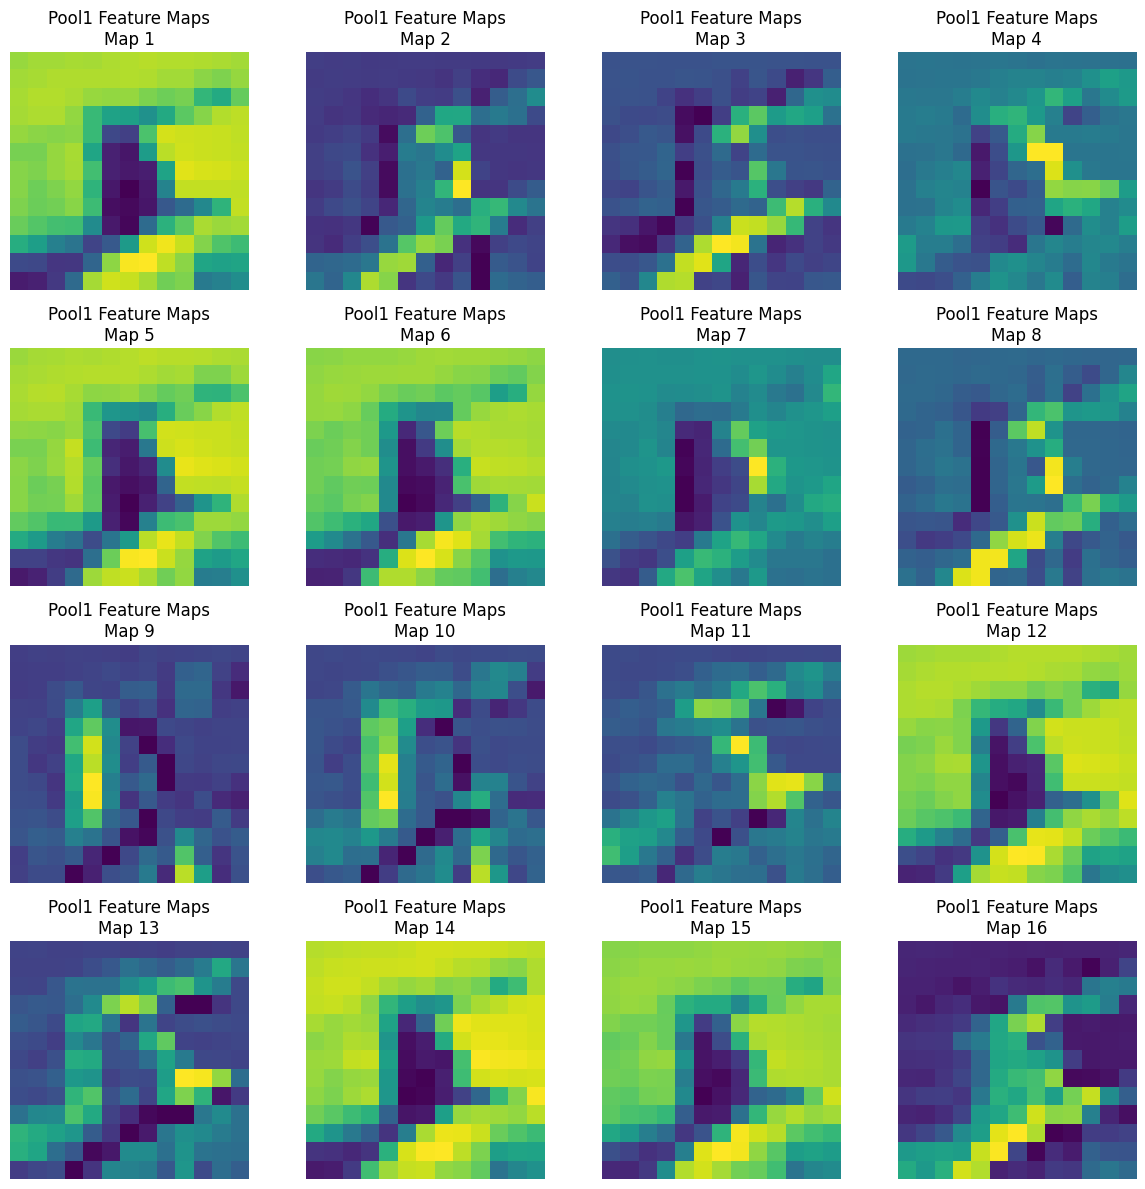

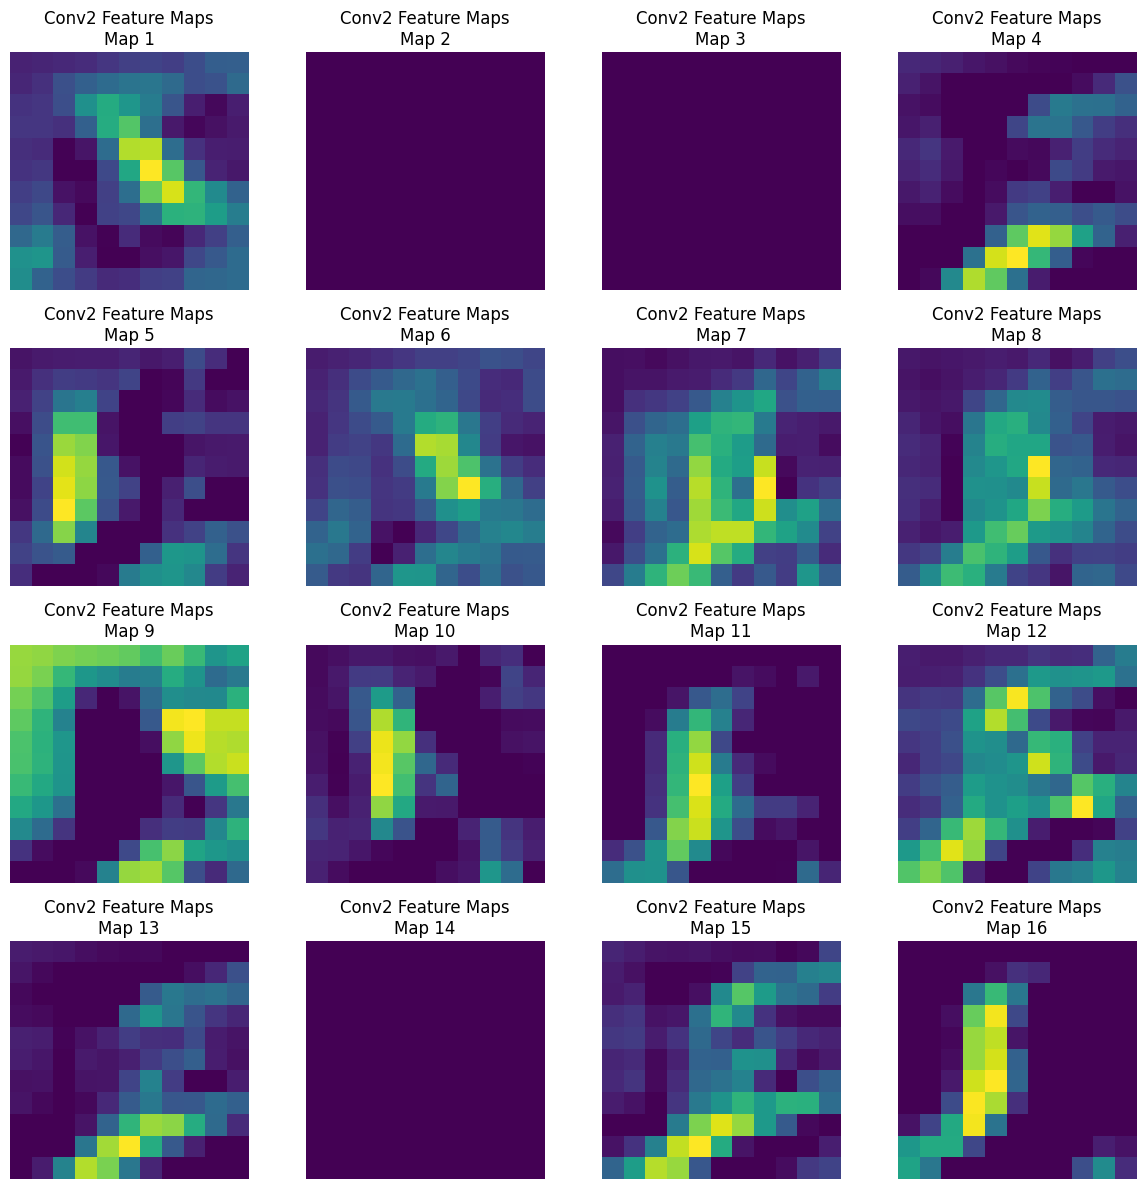

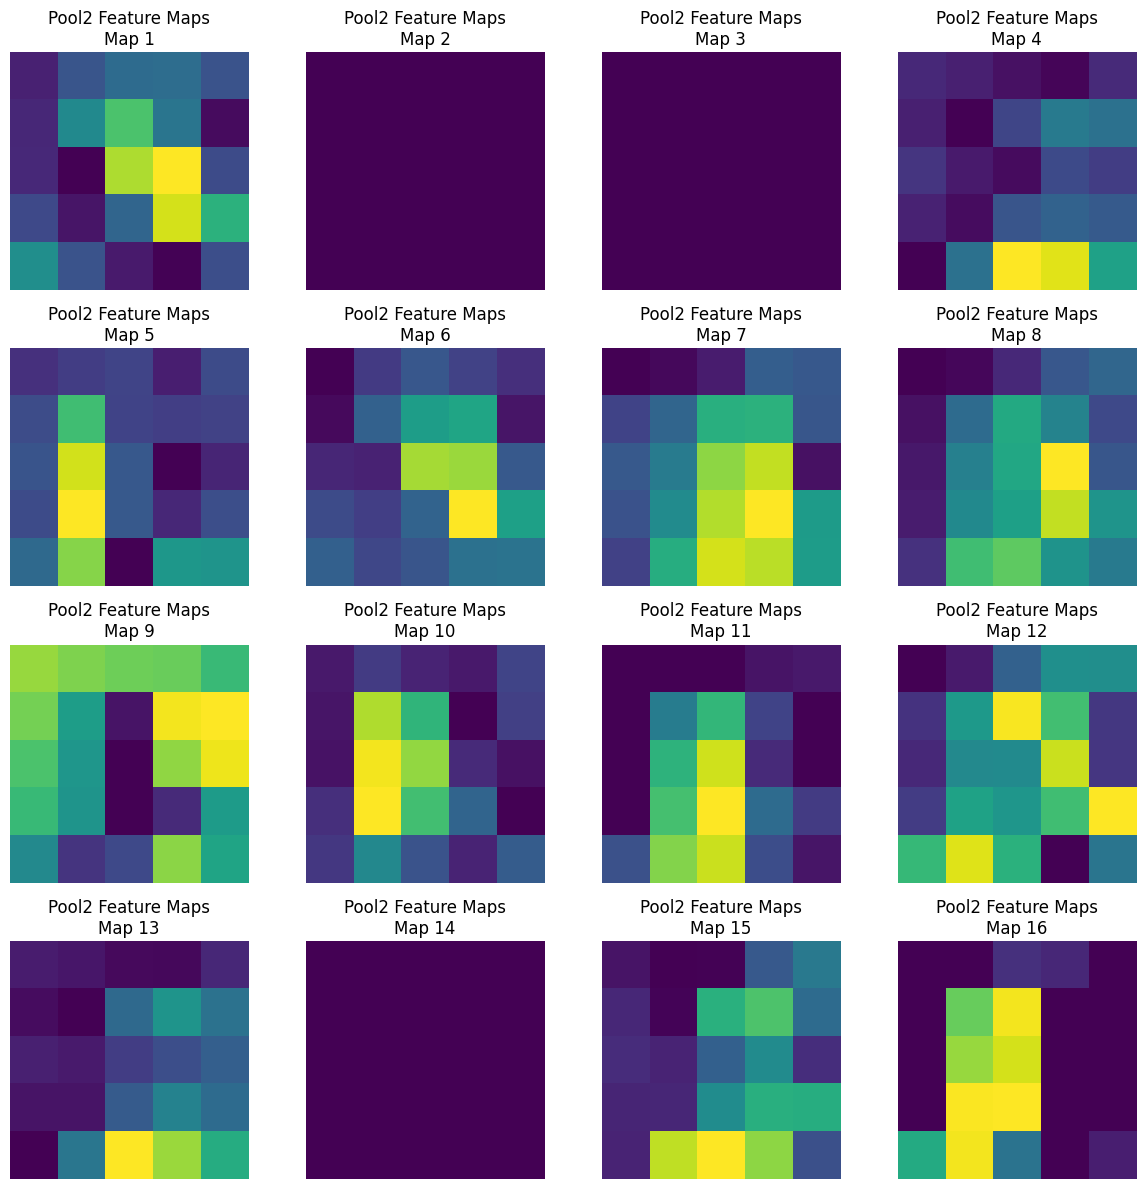

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
X_test = test.iloc[:, 1:].values

# Remap labels to continuous values
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize and reshape
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# Build CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test Accuracy:", test_acc)

# Choose one sample image from test set
img_index = 0
sample_image = X_test[img_index]
sample_label = y_test[img_index]

# Show original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Original Image - Label: {sample_label}")
plt.axis('off')
plt.show()

# Create feature map model
layer_outputs = [
    model.get_layer('conv1').output,
    model.get_layer('pool1').output,
    model.get_layer('conv2').output,
    model.get_layer('pool2').output
]

feature_map_model = Model(inputs=model.inputs, outputs=layer_outputs)

# Predict feature maps
sample_input = np.expand_dims(sample_image, axis=0)
feature_maps = feature_map_model.predict(sample_input, verbose=0)

# Function to display feature maps
def plot_feature_maps(feature_map, title, max_maps=16):
    n_features = min(feature_map.shape[-1], max_maps)
    cols = 4
    rows = (n_features + cols - 1) // cols

    plt.figure(figsize=(12, 3 * rows))
    for i in range(n_features):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_map[0, :, :, i], cmap='viridis')
        plt.title(f"{title}\nMap {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display feature maps
plot_feature_maps(feature_maps[0], "Conv1 Feature Maps")
plot_feature_maps(feature_maps[1], "Pool1 Feature Maps")
plot_feature_maps(feature_maps[2], "Conv2 Feature Maps")
plot_feature_maps(feature_maps[3], "Pool2 Feature Maps")

Train shape: (27455, 785)
Test shape : (7172, 785)
X_train raw shape: (27455, 784)
y_train raw shape: (27455,)
X_test raw shape : (7172, 784)
y_test raw shape : (7172,)

Original labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Mapped labels  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Number of classes: 24

After preprocessing:
X_train shape: (27455, 28, 28, 1)
X_test shape : (7172, 28, 28, 1)
y_train_cat shape: (27455, 24)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5879 - loss: 1.4097 - val_accuracy: 0.8742 - val_loss: 0.4106
Epoch 2/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9387 - loss: 0.2245 - val_accuracy: 0.9925 - val_loss: 0.0749
Epoch 3/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9928 - loss: 0.0515 - val_accuracy: 0.9989 - val_loss: 0.0220
Epoch 4/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9996 - loss: 0.0154 - val_accuracy: 0.9989 - val_loss: 0.0168
Epoch 5/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9994 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0047

Test Accuracy: 0.9057445526123047

Selected image index: 0
True label (mapped): 6
True label (original): 6
Predicted label (mapped): 6
Predicted label (original): 6
Predicted score: 0.9993761

Intermediate step outputs:
Input image shape : (1, 28, 28, 1)
Conv1 output shape: (1, 26, 26, 32)
Pool1 output shape: (1, 13, 13, 32)
Conv2 output shape: (1, 11, 11, 64)


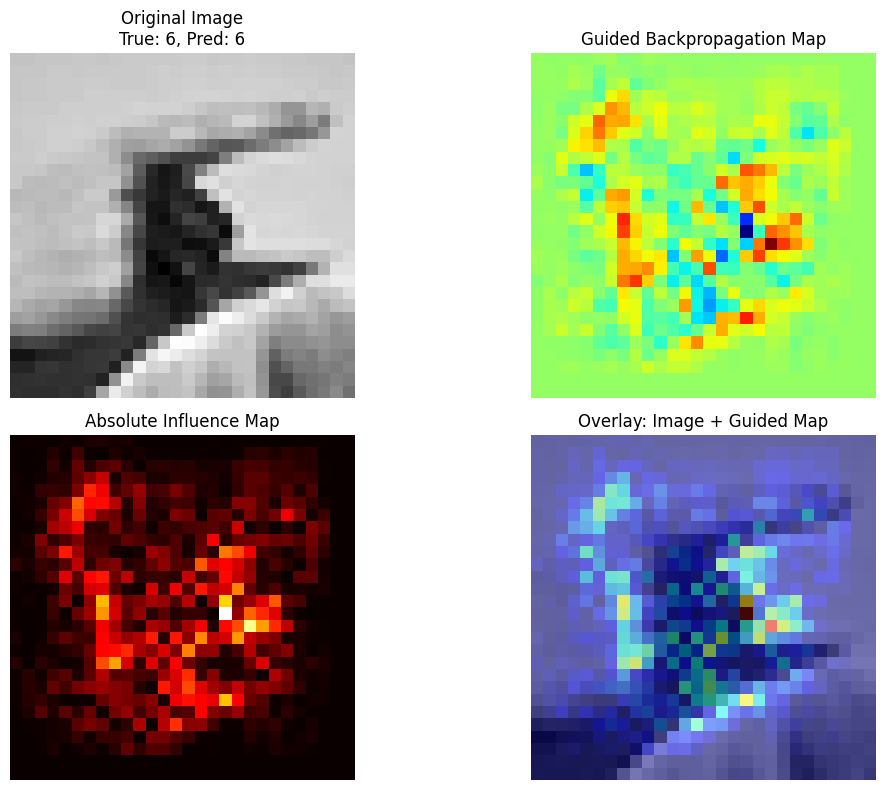

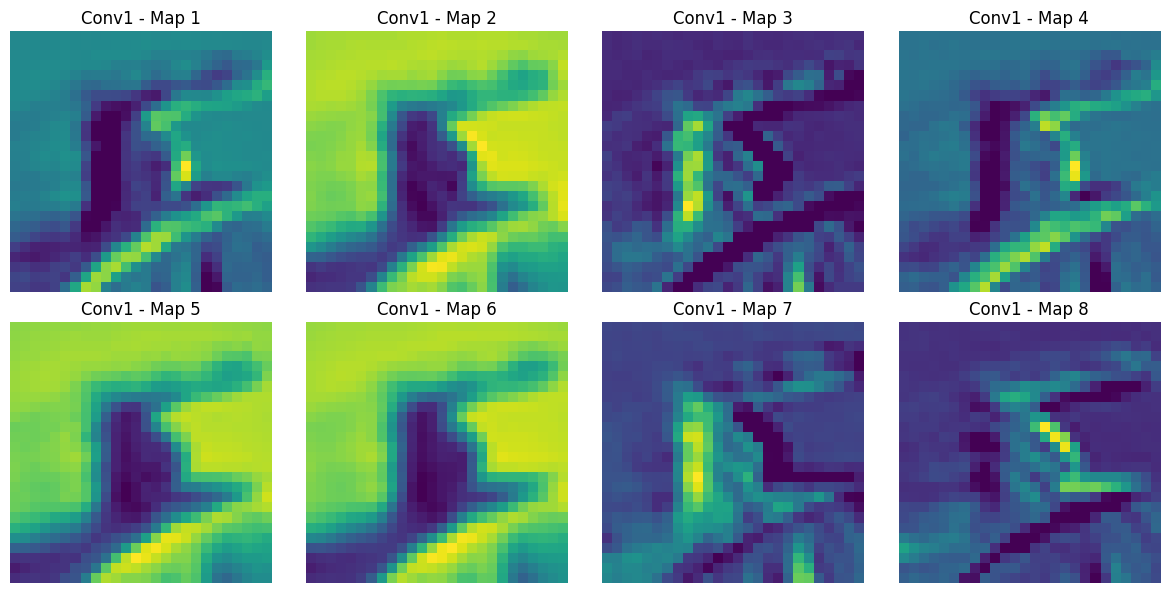

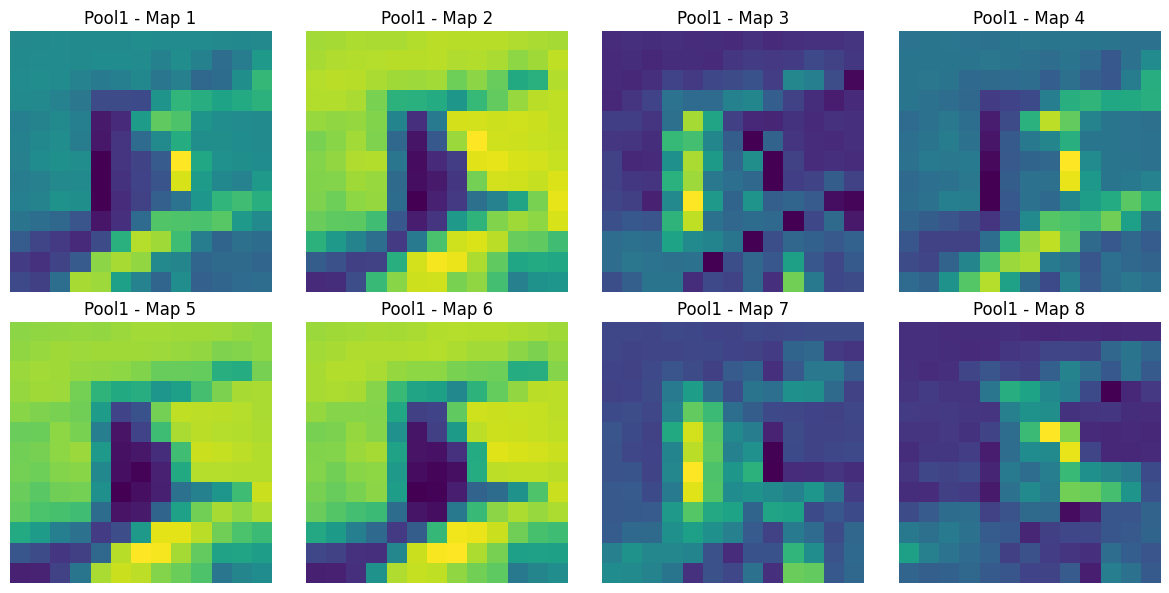

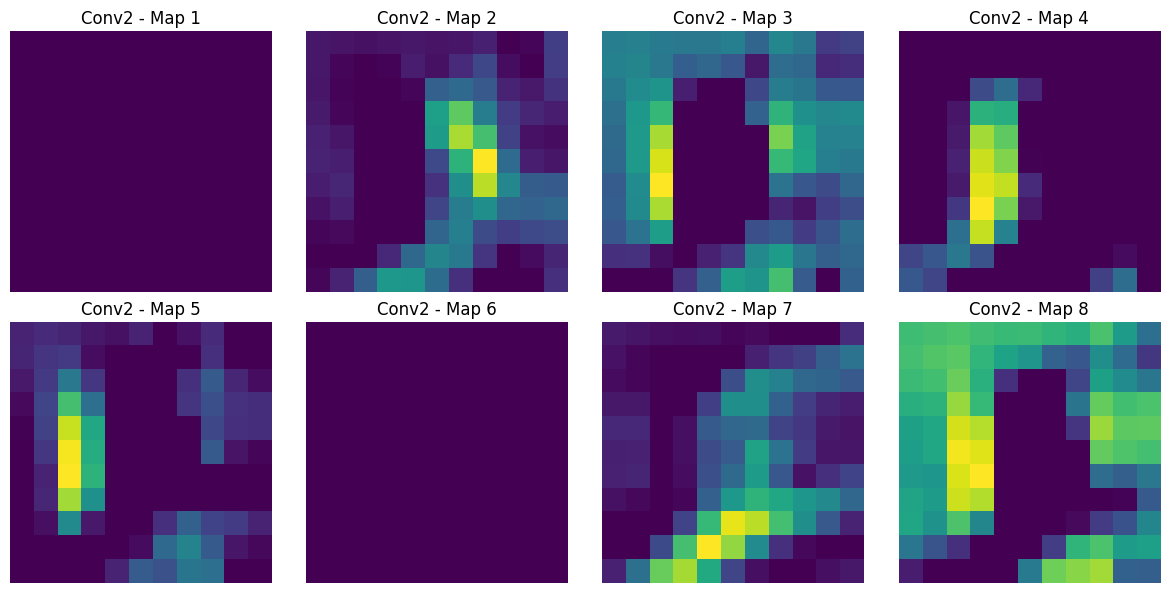

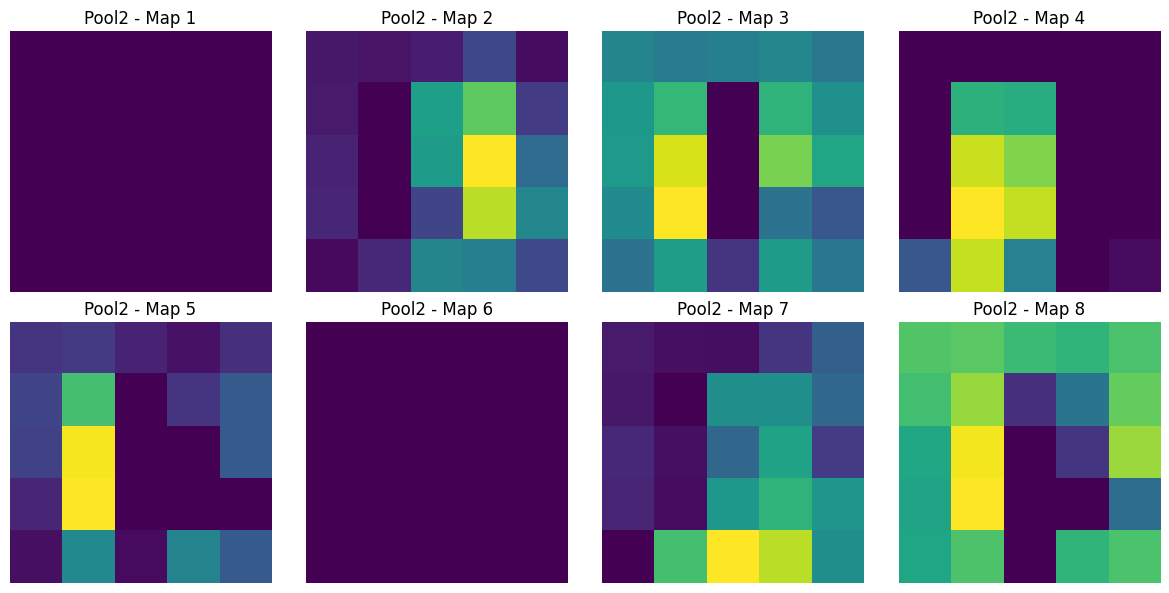

Minimum gradient value: -0.0018674411
Maximum gradient value: 0.0016534093
Mean gradient value   : 6.0780676e-05
Std gradient value    : 0.00030386637

Top 20 most influential pixels (row, col):
1. Pixel (14, 17) -> Gradient: -0.001867
2. Pixel (15, 19) -> Gradient: 0.001653
3. Pixel (13, 17) -> Gradient: -0.001271
4. Pixel (21, 17) -> Gradient: 0.001221
5. Pixel (13, 7) -> Gradient: 0.001197
6. Pixel (18, 8) -> Gradient: 0.001134
7. Pixel (15, 20) -> Gradient: 0.001118
8. Pixel (16, 18) -> Gradient: 0.001103
9. Pixel (14, 7) -> Gradient: 0.001101
10. Pixel (16, 15) -> Gradient: -0.001059
11. Pixel (12, 18) -> Gradient: 0.001044
12. Pixel (17, 14) -> Gradient: 0.001042
13. Pixel (9, 17) -> Gradient: 0.001017
14. Pixel (5, 5) -> Gradient: 0.000957
15. Pixel (14, 19) -> Gradient: 0.000956
16. Pixel (10, 15) -> Gradient: 0.000927
17. Pixel (13, 21) -> Gradient: 0.000926
18. Pixel (6, 5) -> Gradient: 0.000895
19. Pixel (18, 7) -> Gradient: 0.000894
20. Pixel (15, 18) -> Gradient: 0.000893


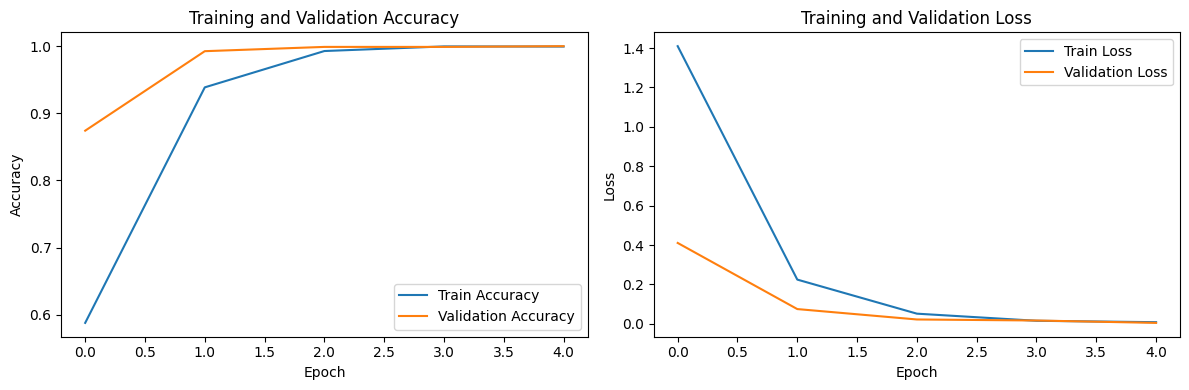


OBSERVATIONS:
1. The model learns important hand-shape features from the Sign MNIST images.
2. Guided Backpropagation highlights pixels that positively influence the predicted class.
3. The most influential pixels are usually concentrated around fingers, palm edges, and hand boundaries.
4. Background pixels generally have less influence on the prediction.
5. Conv1 feature maps capture basic edges and strokes.
6. Conv2 feature maps capture higher-level hand-sign patterns.
7. The overlay map helps identify which parts of the image most affect the classifier decision.
8. Top influential pixel positions provide a numerical explanation of the prediction.


In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Sign MNIST dataset
# -----------------------------
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

y_train_original = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values

y_test_original = test.iloc[:, 0].values
X_test = test.iloc[:, 1:].values

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("X_train raw shape:", X_train.shape)
print("y_train raw shape:", y_train_original.shape)
print("X_test raw shape :", X_test.shape)
print("y_test raw shape :", y_test_original.shape)

# -----------------------------
# 2. Remap labels to continuous values
# -----------------------------
all_labels = sorted(np.unique(np.concatenate([y_train_original, y_test_original])))
label_map = {label: idx for idx, label in enumerate(all_labels)}
reverse_label_map = {idx: label for label, idx in label_map.items()}

y_train = np.array([label_map[label] for label in y_train_original])
y_test = np.array([label_map[label] for label in y_test_original])

num_classes = len(all_labels)

print("\nOriginal labels:", all_labels)
print("Mapped labels  :", sorted(np.unique(y_train)))
print("Number of classes:", num_classes)

# -----------------------------
# 3. Normalize and reshape
# -----------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("\nAfter preprocessing:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

# -----------------------------
# 4. Build and train base CNN model
# -----------------------------
base_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    Flatten(name='flatten'),
    Dense(128, activation='relu', name='fc1'),
    Dense(num_classes, activation='softmax', name='output')
])

base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()

history = base_model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = base_model.evaluate(X_test, y_test_cat, verbose=0)
print("\nTest Accuracy:", test_acc)

# Make sure model is built
_ = base_model.predict(X_test[:1], verbose=0)

# -----------------------------
# 5. Intermediate models
# -----------------------------
conv1_model = Model(inputs=base_model.inputs, outputs=base_model.get_layer("conv1").output)
pool1_model = Model(inputs=base_model.inputs, outputs=base_model.get_layer("pool1").output)
conv2_model = Model(inputs=base_model.inputs, outputs=base_model.get_layer("conv2").output)
pool2_model = Model(inputs=base_model.inputs, outputs=base_model.get_layer("pool2").output)

# -----------------------------
# 6. Guided ReLU
# -----------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, tf.float32) * tf.cast(x > 0, tf.float32) * dy
    return tf.nn.relu(x), grad

# -----------------------------
# 7. Build guided model properly
# -----------------------------
def build_guided_model(num_classes):
    inputs = Input(shape=(28, 28, 1))

    x = Conv2D(32, (3, 3), name='conv1')(inputs)
    x = Activation(guided_relu, name='guided_relu1')(x)
    x = MaxPooling2D((2, 2), name='pool1')(x)

    x = Conv2D(64, (3, 3), name='conv2')(x)
    x = Activation(guided_relu, name='guided_relu2')(x)
    x = MaxPooling2D((2, 2), name='pool2')(x)

    x = Flatten(name='flatten')(x)
    x = Dense(128, name='fc1')(x)
    x = Activation(guided_relu, name='guided_relu3')(x)

    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs, outputs)

guided_model = build_guided_model(num_classes)
guided_model.set_weights(base_model.get_weights())

# -----------------------------
# 8. Select one image
# -----------------------------
img_index = 0
input_image = X_test[img_index:img_index+1]
true_label_mapped = y_test[img_index]
true_label_original = reverse_label_map[true_label_mapped]

# Prediction
predictions = guided_model(input_image, training=False).numpy()
predicted_class_mapped = np.argmax(predictions[0])
predicted_class_original = reverse_label_map[predicted_class_mapped]
predicted_score = predictions[0][predicted_class_mapped]

print("\nSelected image index:", img_index)
print("True label (mapped):", true_label_mapped)
print("True label (original):", true_label_original)
print("Predicted label (mapped):", predicted_class_mapped)
print("Predicted label (original):", predicted_class_original)
print("Predicted score:", predicted_score)

# -----------------------------
# 9. Intermediate forward outputs
# -----------------------------
conv1_out = conv1_model.predict(input_image, verbose=0)
pool1_out = pool1_model.predict(input_image, verbose=0)
conv2_out = conv2_model.predict(input_image, verbose=0)
pool2_out = pool2_model.predict(input_image, verbose=0)

print("\nIntermediate step outputs:")
print("Input image shape :", input_image.shape)
print("Conv1 output shape:", conv1_out.shape)
print("Pool1 output shape:", pool1_out.shape)
print("Conv2 output shape:", conv2_out.shape)
print("Pool2 output shape:", pool2_out.shape)

# -----------------------------
# 10. Guided backpropagation
# -----------------------------
input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    outputs = guided_model(input_tensor, training=False)
    target = outputs[:, predicted_class_mapped]

guided_grads = tape.gradient(target, input_tensor).numpy()[0]

# Use absolute values for influence strength
abs_guided_grads = np.abs(guided_grads[:, :, 0])

# -----------------------------
# 11. Normalize maps for display
# -----------------------------
def normalize_map(x):
    x = x - x.min()
    if x.max() != 0:
        x = x / x.max()
    return x

guided_map = normalize_map(guided_grads[:, :, 0])
abs_guided_map = normalize_map(abs_guided_grads)

# -----------------------------
# 12. Visualize original + guided maps
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(input_image[0, :, :, 0], cmap='gray')
plt.title(f"Original Image\nTrue: {true_label_original}, Pred: {predicted_class_original}")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(guided_map, cmap='jet')
plt.title("Guided Backpropagation Map")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(abs_guided_map, cmap='hot')
plt.title("Absolute Influence Map")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(input_image[0, :, :, 0], cmap='gray')
plt.imshow(abs_guided_map, cmap='jet', alpha=0.5)
plt.title("Overlay: Image + Guided Map")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# 13. Show feature maps
# -----------------------------
def show_feature_maps(feature_maps, title, max_maps=8):
    n = min(feature_maps.shape[-1], max_maps)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.title(f"{title} - Map {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_feature_maps(conv1_out, "Conv1")
show_feature_maps(pool1_out, "Pool1")
show_feature_maps(conv2_out, "Conv2")
show_feature_maps(pool2_out, "Pool2")

# -----------------------------
# 14. Numerical observations
# -----------------------------
print("Minimum gradient value:", guided_grads.min())
print("Maximum gradient value:", guided_grads.max())
print("Mean gradient value   :", guided_grads.mean())
print("Std gradient value    :", guided_grads.std())

top_k = 20
flat_indices = np.argsort(abs_guided_grads.ravel())[::-1][:top_k]
rows, cols = np.unravel_index(flat_indices, abs_guided_grads.shape)

print(f"\nTop {top_k} most influential pixels (row, col):")
for i, (r, c) in enumerate(zip(rows, cols), start=1):
    print(f"{i}. Pixel ({r}, {c}) -> Gradient: {guided_grads[r, c, 0]:.6f}")

# -----------------------------
# 15. Training curves
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 16. Observations
# -----------------------------
print("\nOBSERVATIONS:")
print("1. The model learns important hand-shape features from the Sign MNIST images.")
print("2. Guided Backpropagation highlights pixels that positively influence the predicted class.")
print("3. The most influential pixels are usually concentrated around fingers, palm edges, and hand boundaries.")
print("4. Background pixels generally have less influence on the prediction.")
print("5. Conv1 feature maps capture basic edges and strokes.")
print("6. Conv2 feature maps capture higher-level hand-sign patterns.")
print("7. The overlay map helps identify which parts of the image most affect the classifier decision.")
print("8. Top influential pixel positions provide a numerical explanation of the prediction.")